# Exploratory Data Analysis on the MedlinePlus glossary

In [21]:
from pathlib import Path
import xml.etree.ElementTree as ET
import pandas as pd
import seaborn as sns 
import matplotlib as plt

xml_files = sorted(Path("../../data").glob("*.xml"))

In [22]:
def flatten_xml(element, prefix=""):
    row = {}

    for key, value in element.attrib.items():
        row[f"{prefix}@{key}"] = value

    children = list(element)
    if not children:
        text = (element.text or "").strip()
        if text:
            row[prefix.rstrip(".")] = text
        return row

    seen = {}
    for child in children:
        seen[child.tag] = seen.get(child.tag, 0) + 1

    for child in children:
        key = f"{prefix}{child.tag}"
        if seen[child.tag] > 1:
            key += f"_{sum(1 for c in children[:children.index(child)] if c.tag == child.tag) + 1}"
        row.update(flatten_xml(child, f"{key}."))

    return row

In [23]:
rows = []
for file in xml_files:
    root = ET.parse(file).getroot()
    for record in root.findall(".//definition"):
        row = flatten_xml(record)
        row["source_file"] = file.name
        rows.append(row)

df = pd.DataFrame(rows)
df.head()

,,source_file
0,>Physical activity is any body movement that w...,medlineplus_fitness.xml
1,>Aerobic exercise is activity that moves your ...,medlineplus_fitness.xml
2,>Basal metabolic rate is the measure of the en...,medlineplus_fitness.xml
3,>Body Mass Index (BMI) is an estimate of your ...,medlineplus_fitness.xml
4,>Your physical activity session should end by ...,medlineplus_fitness.xml


Summarize structure, clinical note types, text quality, and use cases.

In [24]:
def analyze_glossary(df):
    """"""
    if df.empty:
        print("No dataset was loaded.")
        return

    print("## Dataset structure")
    print(f"Rows: {len(df):,}")
    print(f"Columns: {len(df.columns)}")
    display(pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing": df.isna().sum().values,
        "missing_%": (df.isna().mean() * 100).round(2).values,
        "unique": [df[c].nunique(dropna=True) for c in df.columns],
    }))

    text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

    if text_cols:
        text_summary = []
        for col in text_cols:
            lengths = df[col].dropna().astype(str).str.len()
            text_summary.append({
                "column": col,
                "avg_chars": round(lengths.mean(), 1) if len(lengths) else 0,
                "median_chars": lengths.median() if len(lengths) else 0,
                "max_chars": lengths.max() if len(lengths) else 0,
                "empty_values": int(df[col].fillna("").astype(str).str.strip().eq("").sum()),
            })

        print("\n## Text characteristics")
        display(pd.DataFrame(text_summary))

    type_candidates = [
        c for c in df.columns
        if any(term in c.lower() for term in ["type", "category", "class", "specialty", "topic"])
    ]

    print("\n## Clinical note or terminology types")
    if type_candidates:
        for col in type_candidates:
            print(f"\n{col}:")
            display(df[col].value_counts(dropna=False).head(20).rename("count").to_frame())
    else:
        print("No explicit note-type, category, specialty, or topic column was detected.")

    print("\n## Missing data")
    missing = df.isna().sum().sort_values(ascending=False)
    display(missing[missing.gt(0)].rename("missing_values").to_frame())

    duplicate_count = int(df.duplicated().sum())
    print(f"Duplicate rows: {duplicate_count:,}")

    print("\n## Potential use cases")
    print("- Search and retrieval of medical terms and definitions")
    print("- Patient-facing health education and glossary applications")
    print("- Clinical NLP vocabulary development and entity normalization")
    print("- Medical question answering and terminology lookup")
    print("- Data quality monitoring for missing, duplicate, or unusually short entries")

    if text_cols:
        length_col = max(
            text_cols,
            key=lambda c: df[c].dropna().astype(str).str.len().mean()
            if df[c].notna().any() else 0
        )
        lengths = df[length_col].dropna().astype(str).str.len()
        if not lengths.empty:
            sns.histplot(lengths, bins=30)
            plt.title(f"Text-length distribution: {length_col}")
            plt.xlabel("Characters")
            plt.ylabel("Entries")
            plt.show()

## Dataset structure
Rows: 97
Columns: 2


,column,dtype,missing,missing_%,unique
0,,str,0,0.0,85
1,source_file,str,0,0.0,5



## Text characteristics


,column,avg_chars,median_chars,max_chars,empty_values
0,,265.3,258.0,795,0
1,source_file,25.3,24.0,30,0



## Clinical note or terminology types
No explicit note-type, category, specialty, or topic column was detected.

## Missing data


,missing_values


Duplicate rows: 0

## Potential use cases
- Search and retrieval of medical terms and definitions
- Patient-facing health education and glossary applications
- Clinical NLP vocabulary development and entity normalization
- Medical question answering and terminology lookup
- Data quality monitoring for missing, duplicate, or unusually short entries


AttributeError: module 'matplotlib' has no attribute 'title'

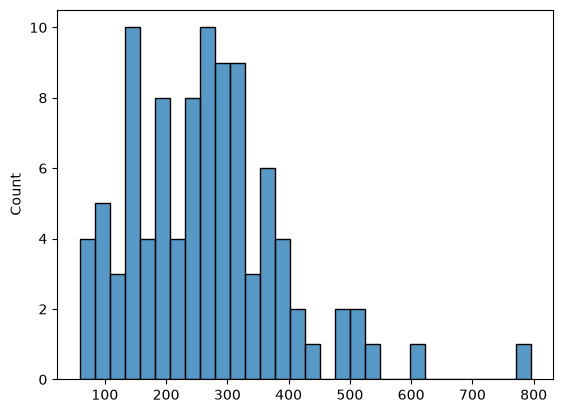

In [25]:
analyze_glossary(df)